In [1]:
%load_ext autoreload
%autoreload 2
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import sys
import importlib
import coffea.util as util
import time
import json
import os
import numba as nb
import awkward.numba

sys.path.append("../analysisTools/")
from analysisTools import Analyzer
from analysisTools import loadSchema
import analysisTools as tools
import analysisSubroutines as routines

In [2]:
# f_bkg = "../configs/sample_configs/skimmed_bkg_2022_WJetsAllHT.json"
# with open(f_bkg,"r") as file:
#     bkg_cfg = json.load(file)
# boc0 = bkg_cfg[0]['location']
# boc1 = bkg_cfg[1]['location']
# boc2 = bkg_cfg[2]['location']

# tb0 = uproot.open(boc0)['ntuples/outT']
# tb1 = uproot.open(boc1)['ntuples/outT']
# tb2 = uproot.open(boc2)['ntuples/outT']

# met_trigb0=tb0["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
# met_trigb1=tb1["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
# met_trigb2=tb2["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()

In [2]:
sample_cfg = "../configs/sample_configs/signal_2022_Mchi_10_30_50_aEM.json"
with open(sample_cfg,"r") as fin:
    sig_cfg = json.load(fin)
loc0 = sig_cfg[0]['location']
loc1 = sig_cfg[1]['location']
loc2 = sig_cfg[2]['location']

In [4]:
#See the quantities in the root file:
t0 = uproot.open(loc0)['ntuples/outT']
print (t0)
t1 = uproot.open(loc1)['ntuples/outT']
t2 = uproot.open(loc2)['ntuples/outT']

<ReadOnlyDirectory '/' at 0x7f49ce880d30>


In [5]:
# Trigger used
met_trig0=t0["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()

met_trig1=t1["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
met_trig2=t2["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()

In [6]:
#Cut for m1=10
PFMET_pt0=t0["PFMET_pt"].array()

CaloMET_pt0=t0["CaloMET_pt"].array()
diff0= abs(PFMET_pt0-CaloMET_pt0)

r0=diff0/(CaloMET_pt0)
cut_sig0=(r0 <0.5)


#Cut for m1=30

PFMET_pt1=t1["PFMET_pt"].array()

CaloMET_pt1=t1["CaloMET_pt"].array()
diff1= abs(PFMET_pt1-CaloMET_pt1)

r1=diff1/(CaloMET_pt1)
cut_sig1=(r1 <0.5)


#Cut for m1=50

PFMET_pt2=t2["PFMET_pt"].array()

CaloMET_pt2=t2["CaloMET_pt"].array()
diff2= abs(PFMET_pt2-CaloMET_pt2)

r2=diff2/(CaloMET_pt2)

cut_sig2=(r2 <0.5)


/tmp/ipykernel_3520297/1406335762.py:17: RuntimeWarning: invalid value encountered in divide
  eff_y0= np.divide(nume0, deno0)
/tmp/ipykernel_3520297/1406335762.py:26: RuntimeWarning: invalid value encountered in divide
  eff_y2= np.divide(nume2, deno2)


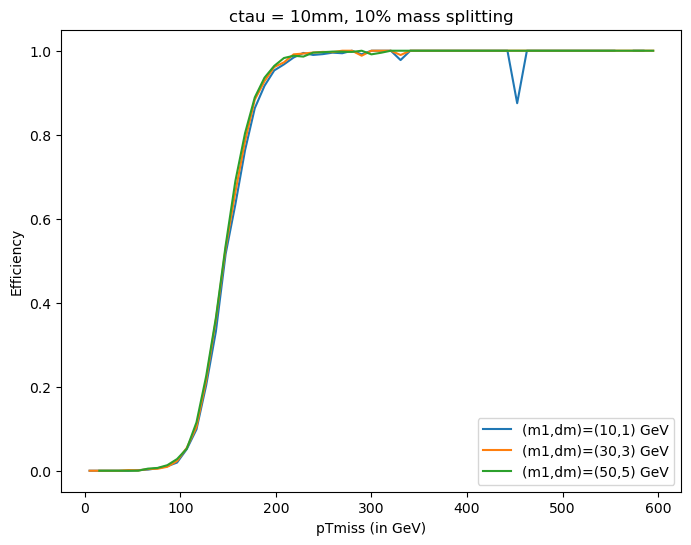

In [9]:
#Aim: To plot the trigger efficiency

pfmet_pass0 = PFMET_pt0[cut_sig0]
met_trig_pass0 = met_trig0[cut_sig0]  

pfmet_pass1 = PFMET_pt1[cut_sig1]
met_trig_pass1 = met_trig1[cut_sig1]  

pfmet_pass2 = PFMET_pt2[cut_sig2]
met_trig_pass2 = met_trig2[cut_sig2]  


bins = np.linspace(0, 600, 60)  

deno0, edges_deno0 = np.histogram(pfmet_pass0, bins=bins)  #Denominator: the ptmiss values that pass the cut
nume0, edges_nume0 = np.histogram(pfmet_pass0[met_trig_pass0], bins=bins) #Numerator: the ptmiss values that pass the MET tigger and the cut applied
eff_y0= np.divide(nume0, deno0)

deno1, edges_deno1 = np.histogram(pfmet_pass1, bins=bins)  #Denominator: the ptmiss values that pass the cut
nume1, edges_nume1 = np.histogram(pfmet_pass1[met_trig_pass1], bins=bins) #Numerator: the ptmiss values that pass the MET tigger and the cut applied
eff_y1= np.divide(nume1, deno1)


deno2, edges_deno2 = np.histogram(pfmet_pass2, bins=bins)  #Denominator: the ptmiss values that pass the cut
nume2, edges_nume2 = np.histogram(pfmet_pass2[met_trig_pass2], bins=bins) #Numerator: the ptmiss values that pass the MET tigger and the cut applied
eff_y2= np.divide(nume2, deno2)


pfmet_pass_bin_x=0.5 * (edges_deno1[:-1] + edges_deno1[1:])
#print (pfmet_bin_x)

plt.figure(figsize=(8,6))
plt.plot(pfmet_pass_bin_x,eff_y0, label='(m1,dm)=(10,1) GeV')
plt.plot(pfmet_pass_bin_x,eff_y1, label='(m1,dm)=(30,3) GeV')
plt.plot(pfmet_pass_bin_x,eff_y2, label='(m1,dm)=(50,5) GeV')

plt.xlabel("pTmiss (in GeV)")  
plt.ylabel("Efficiency")
plt.title("ctau = 10mm, 10% mass splitting")
plt.legend()
plt.savefig("trigger_eff.png")
